# 1. Introduction
**Dataset**

- API call from iNaturalist python module
- Curate from Kaggle

**Latar Belakang**

Bali merupakan salah satu destinasi wisata paling terkenal di Indonesia yang tidak hanya kaya akan budaya, tetapi juga memiliki keanekaragaman hayati yang tinggi. Salah satu kelompok fauna yang penting dalam ekosistem Bali adalah burung, yang berperan sebagai penyeimbang ekosistem sekaligus indikator kesehatan lingkungan karena sensitivitasnya terhadap perubahan habitat.

Seiring dengan meningkatnya aktivitas pariwisata, tekanan terhadap lingkungan alami di Bali juga semakin besar. Perubahan penggunaan lahan, keramaian wisata, dan degradasi habitat berpotensi memengaruhi keberadaan serta dinamika populasi burung. Oleh karena itu, pemantauan populasi burung menjadi salah satu cara penting untuk menilai apakah kondisi alam Bali masih terjaga.

Di sisi lain, burung merupakan objek yang menarik dan sering difoto oleh wisatawan. Hal ini membuka peluang untuk melibatkan wisatawan dalam pengamatan keanekaragaman hayati melalui pendekatan berbasis teknologi.

**Problem**

Saat ini, pemantauan populasi burung di Bali masih didominasi oleh dinas lingkungan hidup, peneliti, atau komunitas pengamat burung, sehingga cakupan data yang diperoleh relatif terbatas. Keterbatasan sumber daya manusia dan waktu menjadi tantangan utama dalam melakukan pemantauan secara luas dan berkelanjutan.

Di tengah perkembangan teknologi, potensi kontribusi wisatawan melalui foto burung yang mereka ambil belum dimanfaatkan secara optimal. Tanpa adanya sistem yang mampu mengenali spesies burung secara otomatis, data visual tersebut belum dapat digunakan secara efektif untuk mendukung pendataan dan konservasi burung di Bali.

**Objective**

Proyek BirdID: Bali bertujuan untuk:

Mengembangkan aplikasi berbasis computer vision yang mampu mengklasifikasikan 15 spesies burung di Bali, terdiri dari spesies yang paling sering ditemukan dan spesies burung yang rentan punah.

Mengedukasi wisatawan mengenai keanekaragaman burung di Bali melalui proses identifikasi berbasis foto.

Mengumpulkan data tambahan berupa foto dan metadata burung yang dapat dimanfaatkan untuk mendukung pendataan populasi burung oleh pihak terkait.

Mendukung upaya pelestarian ekosistem darat sesuai dengan Sustainable Development Goals (SDGs) nomor 15: Life on Land.

# 2. Import Libraries

In [ ]:
# basic
import os
import glob
import random
import warnings

# data handling
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# image processing
import cv2

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')

Mounted at /content/drive


# 3. Data Loading

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/Data_FP_Final/fix'

In [ ]:
classes = sorted(os.listdir(DATASET_PATH))
classes

['Acridotheres_javanicus',
 'Ardea_coromanda',
 'Ardeola_speciosa',
 'Cinnyris_ornatus',
 'Geopelia_striata',
 'Hydrornis_guajanus',
 'Lanius_schach',
 'Leucopsar_rothschildi',
 'Lonchura_leucogastroides',
 'Lonchura_punctulata',
 'Passer_montanus',
 'Pycnonotus_aurigaster',
 'Pycnonotus_goiavier',
 'Spilopelia_chinensis',
 'Todiramphus_chloris']

In [ ]:
print(f"Jumlah spesies burung: {len(classes)}")

Jumlah spesies burung: 15


In [ ]:
image_paths = []
labels = []

image_extensions = ['*.jpg', '*.jpeg', '*.png']

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    for ext in image_extensions:
        files = glob.glob(os.path.join(cls_path, ext))
        image_paths.extend(files)
        labels.extend([cls] * len(files))

In [ ]:
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

df.sample(5)

,image_path,label
2292,/content/drive/MyDrive/Data_FP_Final/fix/Leuco...,Leucopsar_rothschildi
5203,/content/drive/MyDrive/Data_FP_Final/fix/Todir...,Todiramphus_chloris
2265,/content/drive/MyDrive/Data_FP_Final/fix/Leuco...,Leucopsar_rothschildi
3516,/content/drive/MyDrive/Data_FP_Final/fix/Passe...,Passer_montanus
739,/content/drive/MyDrive/Data_FP_Final/fix/Ardeo...,Ardeola_speciosa


In [ ]:
print(f"Total images: {len(df)}")

Total images: 5428


Menetapkan 15 spesies sebagai yang terpilih untuk ditampilkan pada tahap Exploratory Data Analysis (EDA). Kenapa memilih 15 spesies ini? karena 10 diantaranya adalah spesies burung yang paling sering terlihat/terpantau di Daerah Bali, 5 lainnya adalah spesies burung yang sudah terancam punah.

In [ ]:
class_counts = df['label'].value_counts()
class_counts

,count
label,
Ardeola_speciosa,500
Pycnonotus_goiavier,500
Lonchura_leucogastroides,500
Spilopelia_chinensis,500
Lonchura_punctulata,496
Geopelia_striata,459
Passer_montanus,444
Cinnyris_ornatus,433
Ardea_coromanda,389


Jumlah gambar pada 15 spesies burung yang digunakan dalam dataset menunjukkan distribusi yang relatif seimbang, di mana sebagian besar spesies memiliki jumlah data yang cukup besar, berkisar antara ±400 hingga 500 gambar per spesies. Beberapa spesies seperti Ardeola speciosa, Pycnonotus goiavier, Lonchura leucogastroides, dan Spilopelia chinensis memiliki jumlah gambar terbanyak, masing-masing mencapai sekitar 500 gambar.

Namun demikian, terdapat beberapa spesies dengan jumlah data yang lebih terbatas, terutama Hydrornis guajanus dengan 76 gambar, Lanius schach dengan 124 gambar, dan Acridotheres javanicus dengan 143 gambar. Perbedaan jumlah data ini mengindikasikan adanya ketidakseimbangan kelas (class imbalance) pada tingkat tertentu, yang berpotensi memengaruhi performa model pada kelas dengan jumlah data lebih sedikit.

In [ ]:
valid_classes = df['label'].value_counts().index.tolist()

Proses ini dilakukan untuk memastikan bahwa proses analisis dan pemodelan hanya melibatkan kelas yang benar-benar tersedia di dataset, dilakukan ekstraksi daftar kelas menggunakan kolom label. Kelas yang dipilih adalah kelas yang memiliki setidaknya satu sampel data, sehingga kelas kosong (empty class) dapat dihindari.

# 4. Exploratory Data Analysis

## 4.1. Distribusi Jumlah Data per Spesies

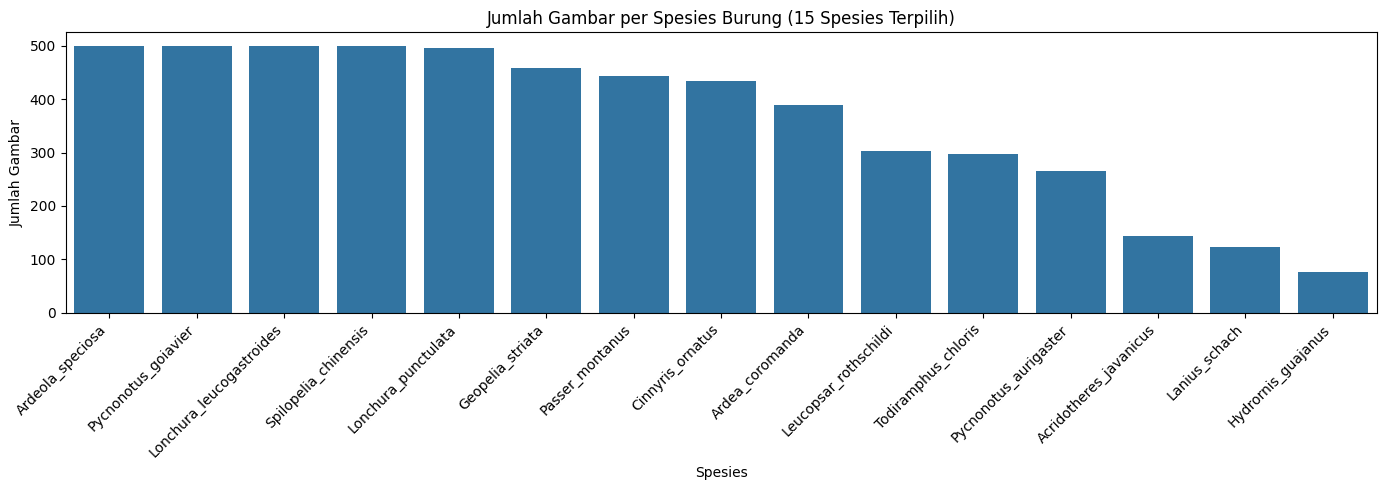

In [ ]:
plt.figure(figsize=(14,5))
sns.countplot(
    data=df,
    x='label',
    order=df['label'].value_counts().index
)

plt.xticks(rotation=45, ha='right')
plt.title('Jumlah Gambar per Spesies Burung (15 Spesies Terpilih)')
plt.xlabel('Spesies')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

Grafik menunjukkan distribusi jumlah gambar pada 15 spesies burung terpilih dengan jumlah data yang bervariasi cukup signifikan antar kelas. Beberapa spesies seperti Ardeola speciosa, Pycnonotus goiavier, Lonchura leucogastroides, dan Spilopelia chinensis memiliki jumlah gambar tertinggi, masing-masing mendekati 500 gambar, sehingga menjadi kelas dengan representasi data paling kuat dalam dataset.

Di sisi lain, terdapat spesies dengan jumlah data yang jauh lebih sedikit, khususnya Hydrornis guajanus, Lanius schach, dan Acridotheres javanicus, yang memiliki jumlah gambar di bawah 150 gambar. Ketimpangan ini mengindikasikan adanya class imbalance, di mana beberapa kelas berpotensi menjadi kelas minoritas dalam proses pelatihan model.

## 4.2. Sampel Visualisasi Gambar per Spesies

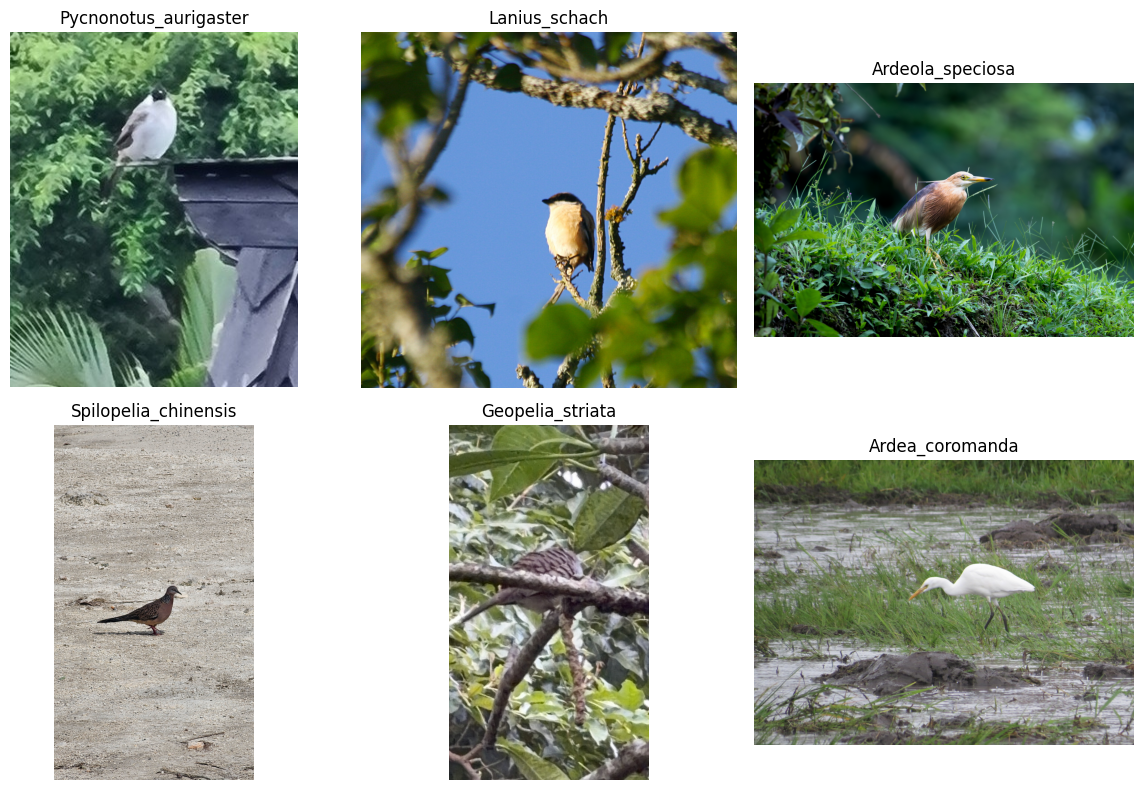

In [ ]:
plt.figure(figsize=(12,8))

sampled_classes = random.sample(
    valid_classes,
    min(6, len(valid_classes))
)

for i, cls in enumerate(sampled_classes):
    img_path = df[df['label'] == cls]['image_path'].iloc[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

Visualisasi sampel citra dari beberapa kelas menunjukkan variasi yang signifikan pada latar belakang, skala objek, dan kualitas gambar. Burung dapat muncul dalam berbagai kondisi lingkungan seperti air, vegetasi, dan langit terbuka, dengan ukuran objek yang tidak konsisten di dalam frame. Selain itu, beberapa spesies memiliki kemiripan visual yang tinggi, khususnya pada genus yang sama, sehingga permasalahan klasifikasi termasuk ke dalam fine-grained image classification. Temuan ini mengindikasikan bahwa model perlu memiliki kemampuan ekstraksi fitur yang kuat dan robust terhadap variasi skala, latar belakang, serta pencahayaan.

## 4.3. Analisis Resolusi Gambar

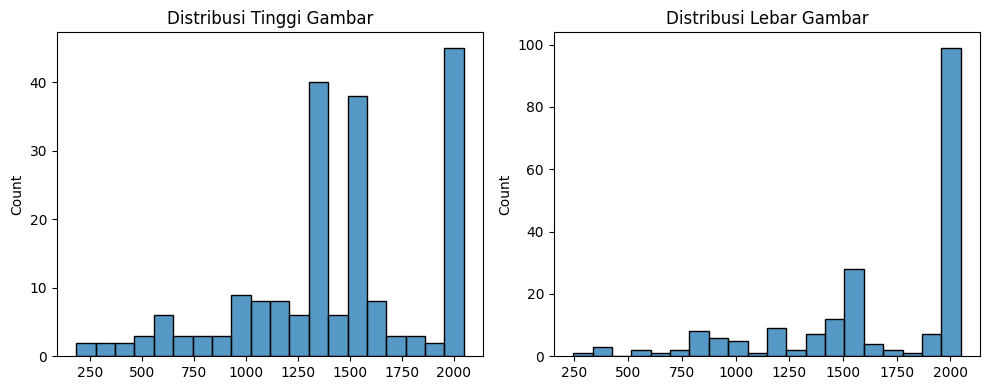

In [ ]:
img_heights = []
img_widths = []

sample_images = random.sample(
    df['image_path'].tolist(),
    min(200, len(df))
)

for img_path in sample_images:
    img = cv2.imread(img_path)
    if img is not None:
        h, w, _ = img.shape
        img_heights.append(h)
        img_widths.append(w)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(img_heights, bins=20)
plt.title('Distribusi Tinggi Gambar')

plt.subplot(1,2,2)
sns.histplot(img_widths, bins=20)
plt.title('Distribusi Lebar Gambar')

plt.tight_layout()
plt.show()

Distribusi resolusi gambar menunjukkan variasi yang cukup signifikan baik pada tinggi maupun lebar gambar. Perbedaan ini mengindikasikan bahwa dataset dikumpulkan dari berbagai sumber dengan karakteristik perangkat yang berbeda. Oleh karena itu, proses resizing dan normalisasi resolusi menjadi langkah penting sebelum data digunakan dalam proses pelatihan model computer vision.

## 4.4. Distribusi Warna RGB (Red Green Blue)

In [ ]:
sample_images = random.sample(
    df['image_path'].tolist(),
    min(200, len(df))
)

r_vals, g_vals, b_vals = [], [], []

for img_path in sample_images:
    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    r, g, b = cv2.split(img)

    r_vals.extend(r.flatten())
    g_vals.extend(g.flatten())
    b_vals.extend(b.flatten())

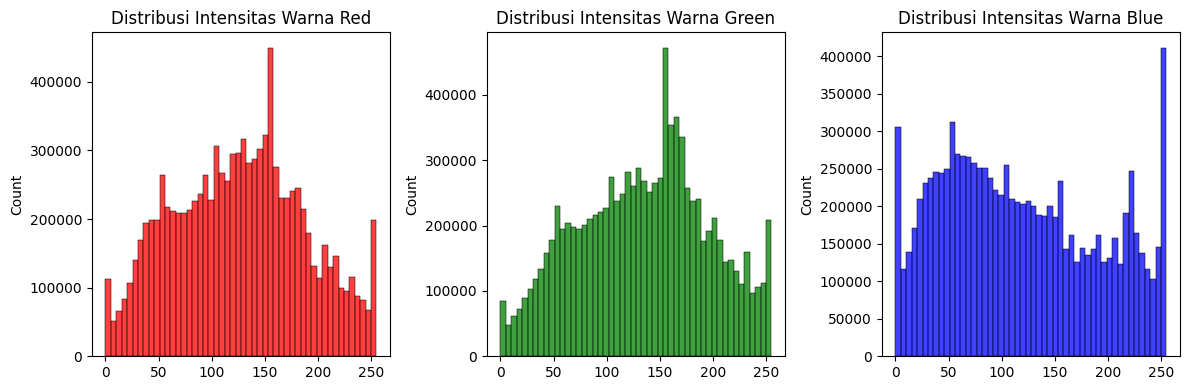

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.histplot(r_vals, bins=50, color='red')
plt.title('Distribusi Intensitas Warna Red')

plt.subplot(1,3,2)
sns.histplot(g_vals, bins=50, color='green')
plt.title('Distribusi Intensitas Warna Green')

plt.subplot(1,3,3)
sns.histplot(b_vals, bins=50, color='blue')
plt.title('Distribusi Intensitas Warna Blue')

plt.tight_layout()
plt.show()

Distribusi intensitas warna menunjukkan bahwa dataset burung Bali didominasi oleh warna hijau dengan variasi signifikan pada channel biru dan intensitas sedang pada channel merah. Pola ini mencerminkan karakteristik habitat alami burung, seperti vegetasi, perairan, dan langit, yang berpotensi memengaruhi proses pembelajaran model jika tidak diimbangi dengan teknik augmentasi dan preprocessing yang tepat.

Sumbu X (0–255) merepresentasikan nilai intensitas pixel pada masing-masing channel warna (Red, Green, dan Blue), di mana nilai 0 menunjukkan warna paling gelap dan 255 menunjukkan warna paling terang. Sumbu Y menunjukkan jumlah pixel (count) yang memiliki nilai intensitas tertentu.

Distribusi intensitas warna menunjukkan bahwa sebagian besar pixel berada pada rentang mid-tone (sekitar 80–160) untuk ketiga channel. Hal ini mengindikasikan bahwa mayoritas gambar memiliki pencahayaan yang cukup seimbang dan tidak didominasi oleh area yang terlalu gelap atau terlalu terang.


## 4.5. Rata-rata Warna per Spesies

In [ ]:
mean_rgb = []

for cls in valid_classes:
    subset = df[df['label'] == cls].sample(
        min(20, len(df[df['label'] == cls]))
    )

    r_mean, g_mean, b_mean = [], [], []

    for img_path in subset['image_path']:
        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))

        r, g, b = cv2.split(img)
        r_mean.append(np.mean(r))
        g_mean.append(np.mean(g))
        b_mean.append(np.mean(b))

    mean_rgb.append([cls, np.mean(r_mean), np.mean(g_mean), np.mean(b_mean)])

rgb_df = pd.DataFrame(mean_rgb, columns=['label','R','G','B'])

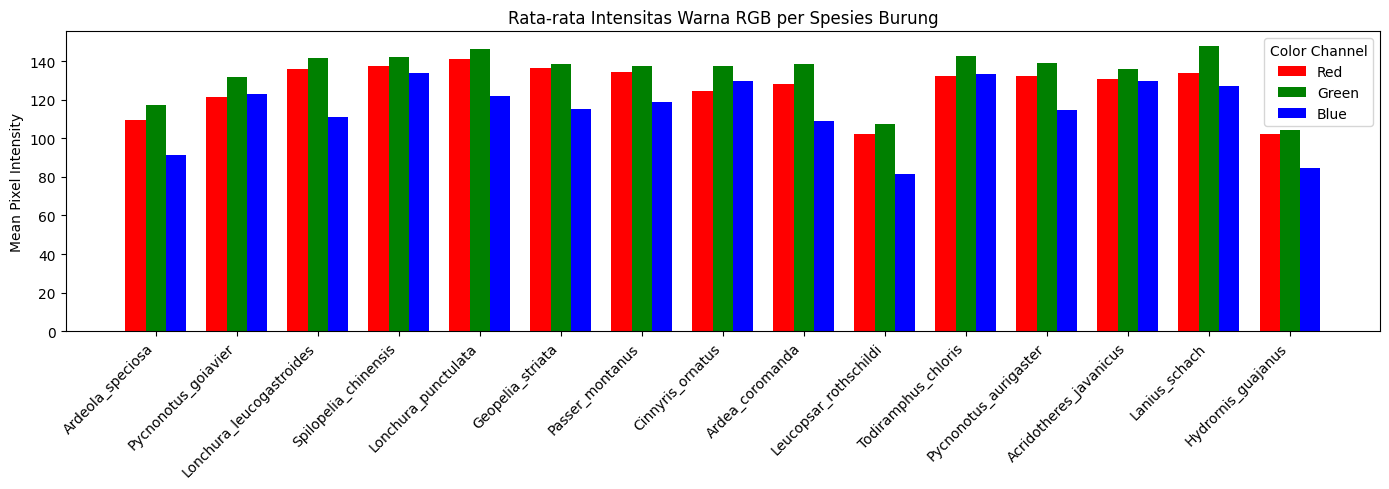

In [ ]:
rgb_plot_df = rgb_df.set_index('label')

labels = rgb_plot_df.index
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(14,5))

plt.bar(x - width, rgb_plot_df['R'], width, label='Red', color='red')
plt.bar(x, rgb_plot_df['G'], width, label='Green', color='green')
plt.bar(x + width, rgb_plot_df['B'], width, label='Blue', color='blue')

plt.xticks(x, labels, rotation=45, ha='right')
plt.ylabel('Mean Pixel Intensity')
plt.title('Rata-rata Intensitas Warna RGB per Spesies Burung')
plt.legend(title='Color Channel')
plt.tight_layout()
plt.show()

Visualisasi rata-rata intensitas warna RGB per spesies menunjukkan bahwa hijau dan merah cenderung lebih dominan dibandingkan biru pada sebagian besar spesies. Hal ini mencerminkan karakteristik citra yang diambil di lingkungan alami dengan latar vegetasi dan langit. Perbedaan komposisi warna antar spesies juga mengindikasikan bahwa informasi warna dapat berkontribusi dalam proses klasifikasi berbasis convolutional neural network.